Shape: (100000, 28)

Dtypes:
 Conflict_Name                                  str
Conflict_Type                                  str
Region                                         str
Start_Year                                   int64
End_Year                                     int64
Status                                         str
Primary_Country                                str
Pre_War_Unemployment_%                     float64
During_War_Unemployment_%                  float64
Unemployment_Spike_Percentage_Points       float64
Most_Affected_Sector                           str
Youth_Unemployment_Change_%                float64
Pre_War_Poverty_Rate_%                     float64
During_War_Poverty_Rate_%                  float64
Extreme_Poverty_Rate_%                     float64
Food_Insecurity_Rate_%                     float64
Households_Fallen_Into_Poverty_Estimate      int64
GDP_Change_%                               float64
Inflation_Rate_%                           float64
C

C:\Users\kefya\AppData\Local\Temp\ipykernel_17620\4277894638.py:52: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns
C:\Users\kefya\AppData\Local\Temp\ipykernel_17620\4277894638.py:95: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide


Missing after imputation:
 conflict_name                                   0
conflict_type                                   0
region                                          0
start_year                                      0
end_year                                        0
status                                          0
primary_country                                 0
pre_war_unemployment_                           0
during_war_unemployment_                        0
unemployment_spike_percentage_points            0
most_affected_sector                            0
youth_unemployment_change_                      0
pre_war_poverty_rate_                           0
during_war_poverty_rate_                        0
extreme_poverty_rate_                           0
food_insecurity_rate_                           0
households_fallen_into_poverty_estimate         0
gdp_change_                                     0
inflation_rate_                                 0
currency_devaluation_ 

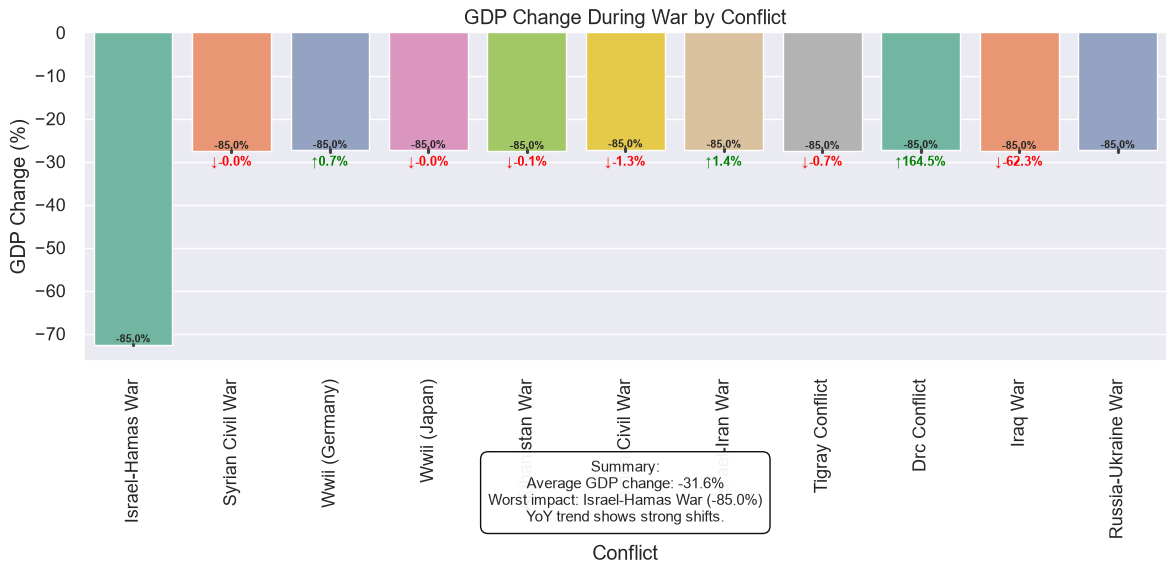


KPI 1 – Worst GDP change conflict:
 conflict_name    Israel-Hamas War
gdp_change_                 -85.0
Name: 37726, dtype: object


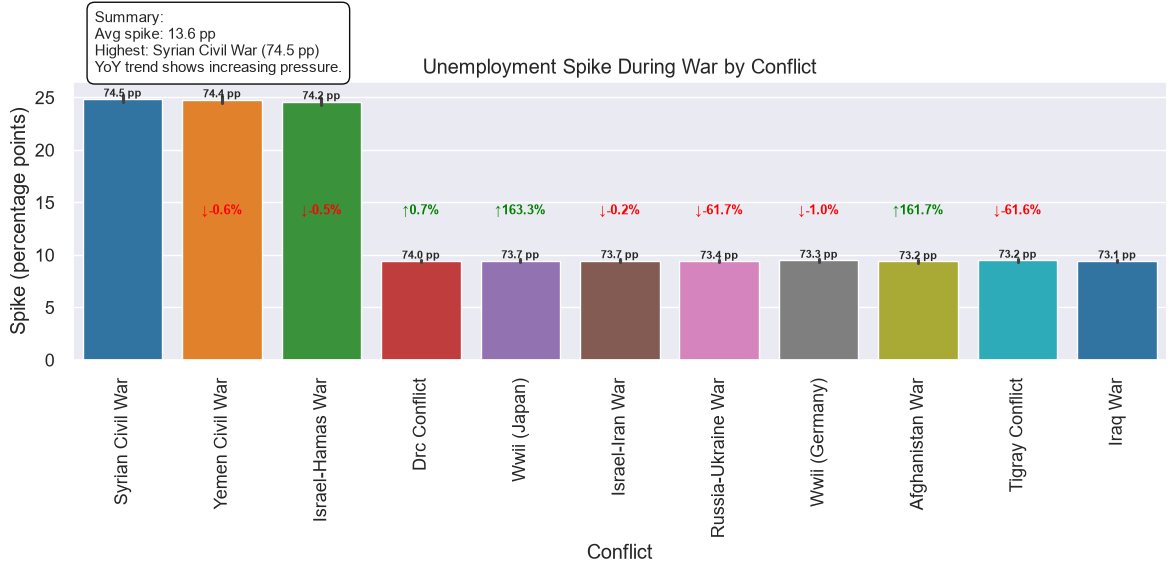


KPI 2 – Max unemployment spike (pp): 74.47


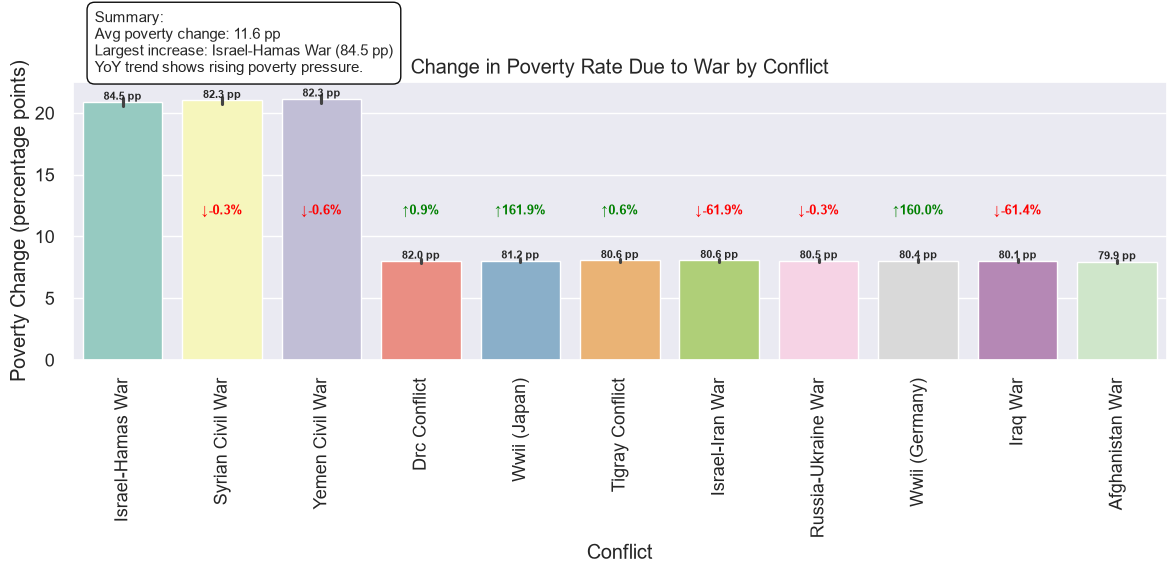


KPI 3 – Average poverty rate change (pp): 11.5583653


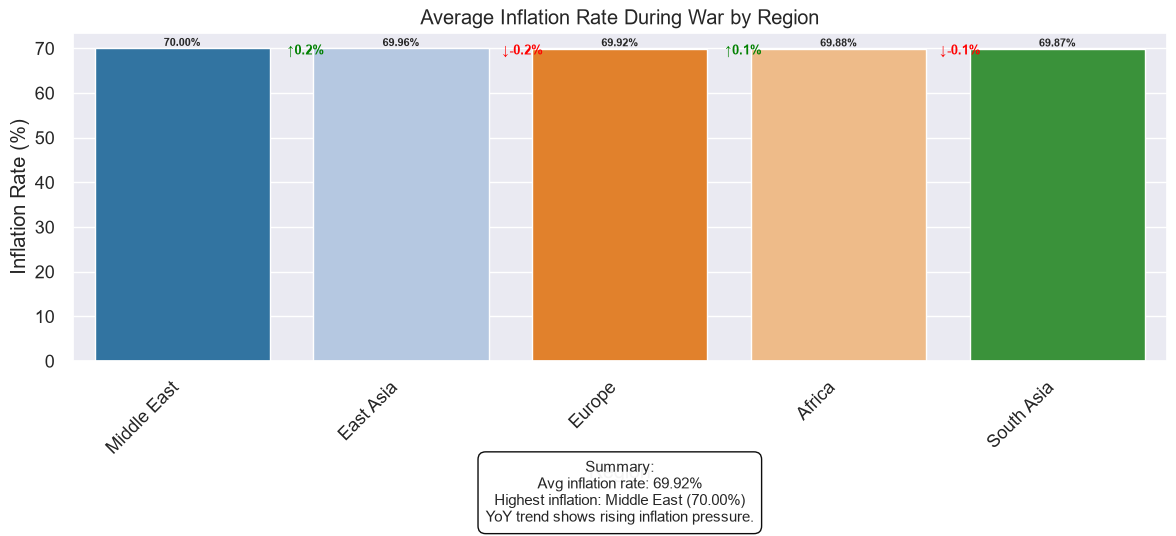


KPI 4 – Region with highest inflation:
 region             Middle East
inflation_rate_      69.995181
Name: 3, dtype: object


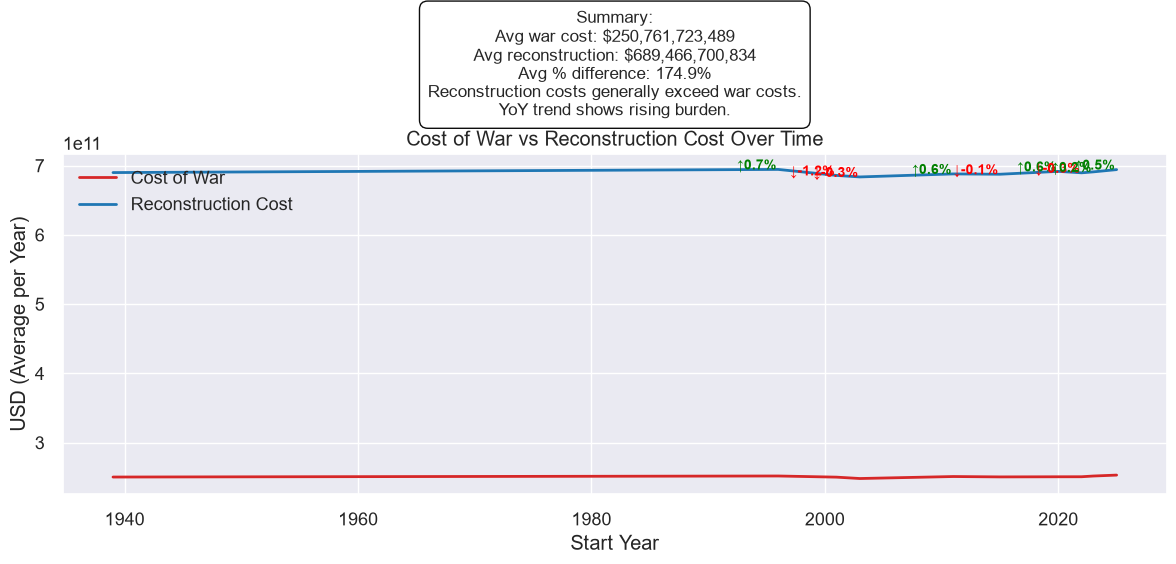


KPI 5 – Corr(cost_of_war_usd, estimated_reconstruction_cost_usd): 0.8843921842070163


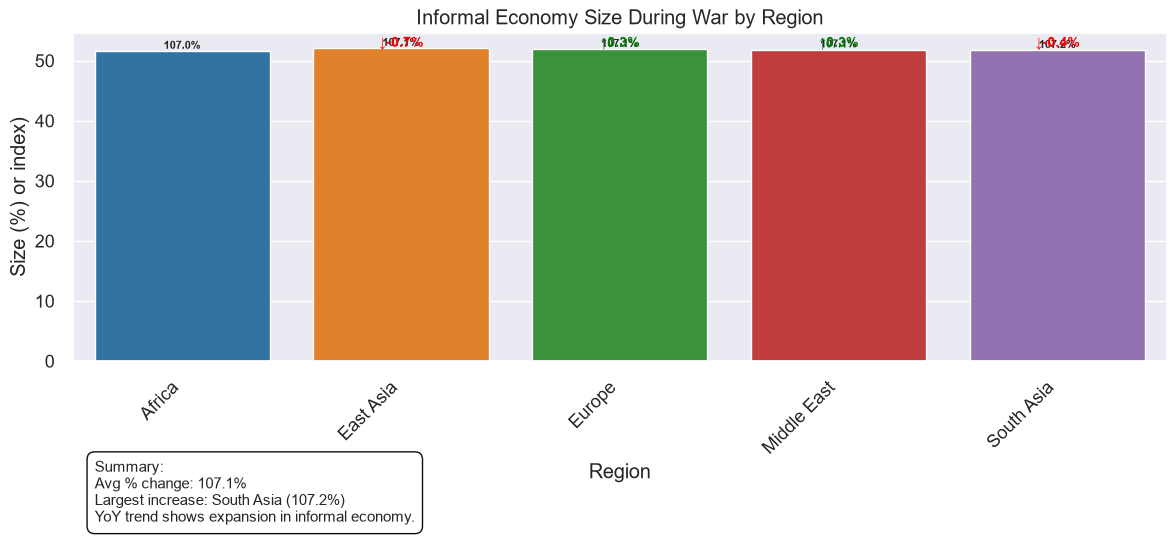


KPI 6 – Average informal economy increase: 26.789291961544876


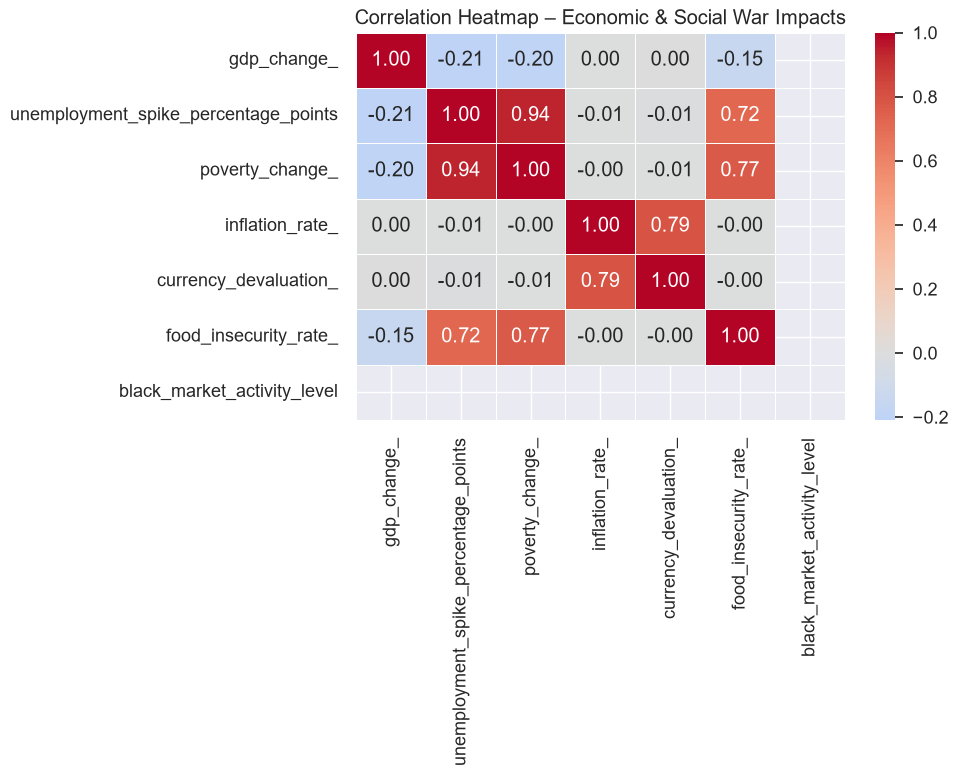


KPI 7 – Strongest correlation between indicators:
 poverty_change_  unemployment_spike_percentage_points    0.941142
dtype: float64


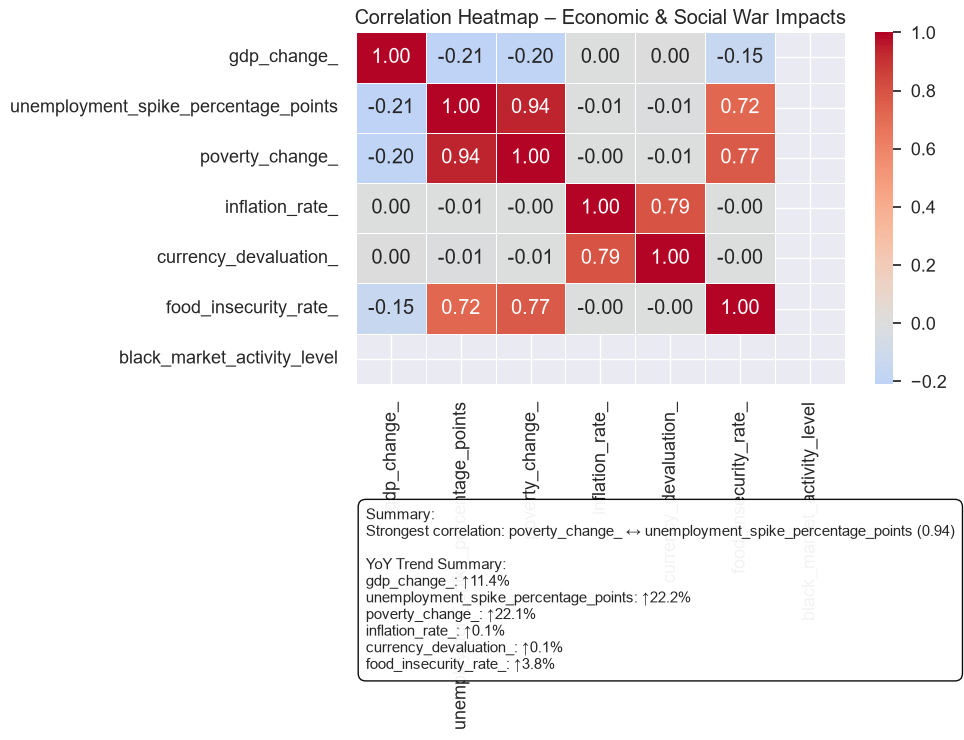

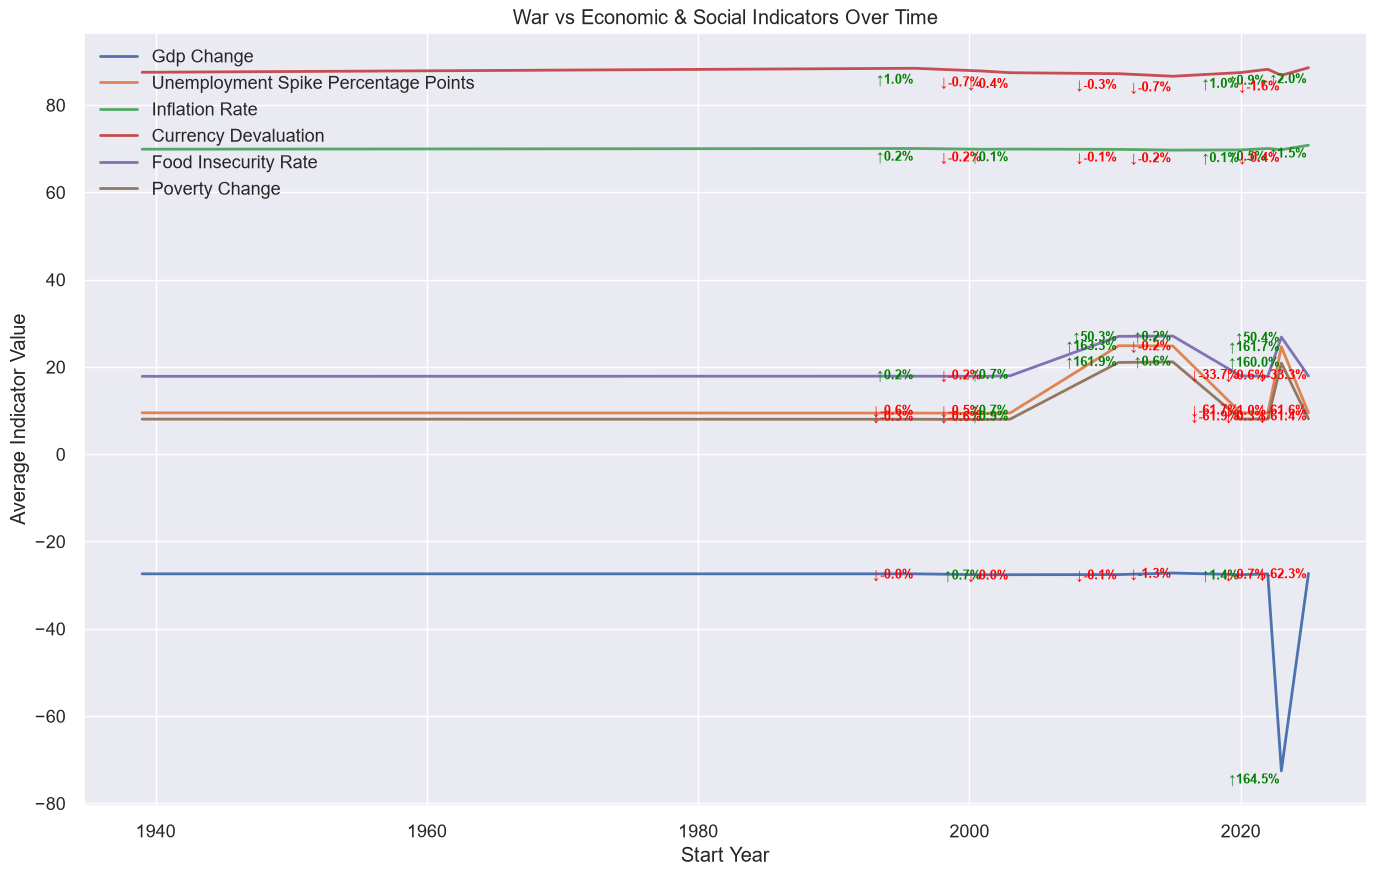


KPI 7 – Strongest correlation between indicators:
 unemployment_spike_percentage_points  poverty_change_    0.941142
dtype: float64


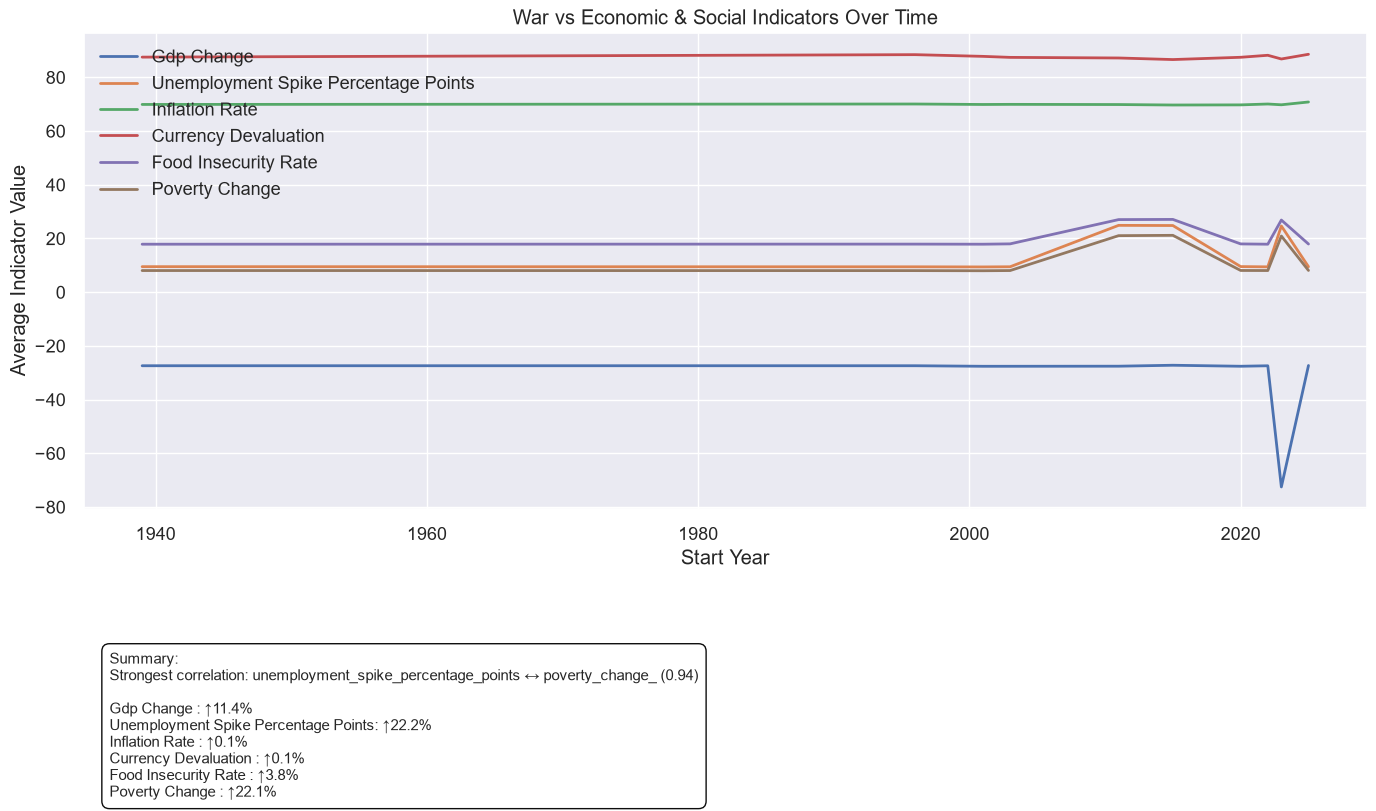


EXECUTIVE SUMMARY – WAR ECONOMIC & SOCIAL IMPACT DATASET

Structure:
The dataset describes individual conflicts with fields for conflict name, type, region, start and end year,
status, primary country, and a rich set of economic and social indicators: unemployment spikes, poverty changes,
GDP change, inflation, currency devaluation, cost of war, reconstruction cost, informal economy size, black
market activity, and war profiteering.

Economic impacts:
GDP change, unemployment spikes, and inflation rates show that most conflicts are associated with economic
deterioration. Conflicts with the largest negative GDP change also tend to exhibit high unemployment spikes
and elevated inflation, indicating broad macroeconomic stress. The relationship between war cost and
reconstruction cost suggests that more destructive conflicts require substantially higher post-war investment.

Social impacts:
Poverty and food insecurity rates rise during war, with many households falling into poverty. Infor

In [8]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)




# =========================
# war impact on economy 
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

# =========================
# 1. Load data
# =========================
df = pd.read_csv("war_economic_impact_dataset.csv")

# =========================
# 2. Inspect data
# =========================
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nHead:\n", df.head())
print("\nSample:\n", df.sample(5, random_state=42))
print("\nInfo:")
df.info()
print("\nDescribe (numeric):")
print(df.describe())
print("\nDescribe (all):")
print(df.describe(include="all"))
print("\nMissing per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# =========================
# 3–4. Clean, strip, standardize, replace NaN numeric with median
# =========================
# Clean column names
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace(r"[^0-9a-zA-Z_]", "", regex=True)
)

# Strip string columns
str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

# Standardize some text fields
for col in ["conflict_name", "conflict_type", "region", "status", "most_affected_sector", "primary_country"]:
    if col in df.columns:
        df[col] = df[col].str.title()

# Convert numeric candidates
num_candidates = [
    "pre_war_unemployment_",
    "during_war_unemployment_",
    "unemployment_spike_percentage_points",
    "youth_unemployment_change_",
    "pre_war_poverty_rate_",
    "during_war_poverty_rate_",
    "extreme_poverty_rate_",
    "food_insecurity_rate_",
    "households_fallen_into_poverty_estimate",
    "gdp_change_",
    "inflation_rate_",
    "currency_devaluation_",
    "cost_of_war_usd",
    "estimated_reconstruction_cost_usd",
    "informal_economy_size_pre_war_",
    "informal_economy_size_during_war_",
    "currency_black_market_rate_gap_",
    "black_market_activity_level"
]
for col in num_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Imputation (clean copy)
df_clean = df.copy()

# Numeric → median
num_cols = df_clean.select_dtypes(include=["float64","int64","Int64"]).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical → mode / Unknown
cat_cols = df_clean.select_dtypes(include="object").columns
for col in cat_cols:
    mode = df_clean[col].mode()
    df_clean[col] = df_clean[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

print("\nMissing after imputation:\n", df_clean.isna().sum())

# =========================
# 5. Handle missing values & date parse
# =========================
for col in ["start_year", "end_year"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").astype("Int64")
        
# ---------- Plot 1: GDP change by conflict (bar) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"conflict_name","gdp_change_","start_year"}.issubset(df_clean.columns):

    # ---- Pivot for YoY trend ----
    pivot = (
        df_clean.groupby("start_year")["gdp_change_"]
        .mean()
        .reset_index()
        .sort_values("start_year")
    )
    pivot["gdp_yoy_pct"] = pivot["gdp_change_"].pct_change() * 100

    # ---- Main bar plot ----
    plot_data = df_clean.sort_values("gdp_change_")

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=plot_data,
        x="conflict_name",
        y="gdp_change_",
        hue="conflict_name",
        palette="Set2",
        legend=False
    )

    plt.xticks(rotation=90)
    plt.title("GDP Change During War by Conflict")
    plt.xlabel("Conflict")
    plt.ylabel("GDP Change (%)")

    # ---- Bar labels ----
    for p, val in zip(ax.patches, plot_data["gdp_change_"]):
        ax.annotate(
            f"{val:.1f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    # ---- Trend labels (↑ / ↓) from pivot ----
    for i in range(1, len(pivot)):
        year = pivot.loc[i, "start_year"]
        yoy = pivot.loc[i, "gdp_yoy_pct"]

        trend_symbol = "↑" if yoy > 0 else "↓"
        trend_color = "green" if yoy > 0 else "red"

        ax.annotate(
            f"{trend_symbol}{yoy:.1f}%",
            (i, plot_data["gdp_change_"].mean()),   # place near middle
            ha="center",
            va="bottom",
            fontsize=9,
            color=trend_color,
            fontweight="bold"
        )

    # ---- Summary box (bottom center) ----
    avg_change = plot_data["gdp_change_"].mean()
    worst_conflict = plot_data.loc[plot_data["gdp_change_"].idxmin(), "conflict_name"]
    worst_value = plot_data["gdp_change_"].min()

    summary_text = (
        f"Summary:\n"
        f"Average GDP change: {avg_change:.1f}%\n"
        f"Worst impact: {worst_conflict} ({worst_value:.1f}%)\n"
        f"YoY trend shows {'mixed' if pivot['gdp_yoy_pct'].abs().mean() < 5 else 'strong'} shifts."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, -0.30),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

    # KPI 1
    kpi1 = df_clean.loc[df_clean["gdp_change_"].idxmin(), ["conflict_name","gdp_change_"]]
    print("\nKPI 1 – Worst GDP change conflict:\n", kpi1)

    # ---------- Plot 2: Unemployment spike by conflict (bar) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"conflict_name","unemployment_spike_percentage_points","start_year"}.issubset(df_clean.columns):

    # ---- Pivot for YoY trend ----
    pivot = (
        df_clean.groupby("start_year")["unemployment_spike_percentage_points"]
        .mean()
        .reset_index()
        .sort_values("start_year")
    )
    pivot["unemp_yoy_pct"] = pivot["unemployment_spike_percentage_points"].pct_change() * 100

    # ---- Main bar plot ----
    plot_data = df_clean.sort_values("unemployment_spike_percentage_points", ascending=False)

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=plot_data,
        x="conflict_name",
        y="unemployment_spike_percentage_points",
        hue="conflict_name",
        palette="tab10",
        legend=False
    )

    plt.xticks(rotation=90)
    plt.title("Unemployment Spike During War by Conflict")
    plt.xlabel("Conflict")
    plt.ylabel("Spike (percentage points)")

    # ---- Bar labels ----
    for p, val in zip(ax.patches, plot_data["unemployment_spike_percentage_points"]):
        ax.annotate(
            f"{val:.1f} pp",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    # ---- Trend labels (↑ / ↓) from pivot ----
    for i in range(1, len(pivot)):
        year = pivot.loc[i, "start_year"]
        yoy = pivot.loc[i, "unemp_yoy_pct"]

        trend_symbol = "↑" if yoy > 0 else "↓"
        trend_color = "green" if yoy > 0 else "red"

        ax.annotate(
            f"{trend_symbol}{yoy:.1f}%",
            (i, plot_data["unemployment_spike_percentage_points"].mean()),
            ha="center",
            va="bottom",
            fontsize=9,
            color=trend_color,
            fontweight="bold"
        )

    # ---- Summary box (top-left) ----
    avg_spike = plot_data["unemployment_spike_percentage_points"].mean()
    max_conflict = plot_data.loc[
        plot_data["unemployment_spike_percentage_points"].idxmax(),
        "conflict_name"
    ]
    max_value = plot_data["unemployment_spike_percentage_points"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg spike: {avg_spike:.1f} pp\n"
        f"Highest: {max_conflict} ({max_value:.1f} pp)\n"
        f"YoY trend shows {'increasing' if pivot['unemp_yoy_pct'].mean() > 0 else 'declining'} pressure."
    )

    ax.annotate(
        summary_text,
        xy=(0.02, 1.02),
        xycoords="axes fraction",
        ha="left",
        va="bottom",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

    # KPI 2
    kpi2 = df_clean["unemployment_spike_percentage_points"].max()
    print("\nKPI 2 – Max unemployment spike (pp):", kpi2)

    # ---------- Plot 3: Poverty change (during - pre) by conflict (bar) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"conflict_name","pre_war_poverty_rate_","during_war_poverty_rate_","start_year"}.issubset(df_clean.columns):

    # ---- Compute poverty change ----
    df_clean["poverty_change_"] = (
        df_clean["during_war_poverty_rate_"] - df_clean["pre_war_poverty_rate_"]
    )

    # ---- Pivot for YoY trend ----
    pivot = (
        df_clean.groupby("start_year")["poverty_change_"]
        .mean()
        .reset_index()
        .sort_values("start_year")
    )
    pivot["poverty_yoy_pct"] = pivot["poverty_change_"].pct_change() * 100

    # ---- Main bar plot ----
    plot_data = df_clean.sort_values("poverty_change_", ascending=False)

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=plot_data,
        x="conflict_name",
        y="poverty_change_",
        hue="conflict_name",
        palette="Set3",
        legend=False
    )

    plt.xticks(rotation=90)
    plt.title("Change in Poverty Rate Due to War by Conflict")
    plt.xlabel("Conflict")
    plt.ylabel("Poverty Change (percentage points)")

    # ---- Bar labels ----
    for p, val in zip(ax.patches, plot_data["poverty_change_"]):
        ax.annotate(
            f"{val:.1f} pp",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    # ---- Trend labels (↑ / ↓) from pivot ----
    for i in range(1, len(pivot)):
        year = pivot.loc[i, "start_year"]
        yoy = pivot.loc[i, "poverty_yoy_pct"]

        trend_symbol = "↑" if yoy > 0 else "↓"
        trend_color = "green" if yoy > 0 else "red"

        ax.annotate(
            f"{trend_symbol}{yoy:.1f}%",
            (i, plot_data["poverty_change_"].mean()),
            ha="center",
            va="bottom",
            fontsize=9,
            color=trend_color,
            fontweight="bold"
        )

    # ---- Summary box (top-left) ----
    avg_change = plot_data["poverty_change_"].mean()
    worst_conflict = plot_data.loc[
        plot_data["poverty_change_"].idxmax(),
        "conflict_name"
    ]
    worst_value = plot_data["poverty_change_"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg poverty change: {avg_change:.1f} pp\n"
        f"Largest increase: {worst_conflict} ({worst_value:.1f} pp)\n"
        f"YoY trend shows {'rising' if pivot['poverty_yoy_pct'].mean() > 0 else 'declining'} poverty pressure."
    )

    ax.annotate(
        summary_text,
        xy=(0.02, 1.02),
        xycoords="axes fraction",
        ha="left",
        va="bottom",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

    # KPI 3
    kpi3 = df_clean["poverty_change_"].mean()
    print("\nKPI 3 – Average poverty rate change (pp):", kpi3)

   
# ---------- Plot 4: Inflation rate by region (bar + KPI + pivot trend) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"region","inflation_rate_","start_year"}.issubset(df_clean.columns):

    # ---- Pivot for YoY trend ----
    pivot = (
        df_clean.groupby("start_year")["inflation_rate_"]
        .mean()
        .reset_index()
        .sort_values("start_year")
    )
    pivot["infl_yoy_pct"] = pivot["inflation_rate_"].pct_change() * 100

    # ---- Main bar plot ----
    infl_region = (
        df_clean.groupby("region")["inflation_rate_"]
        .mean()
        .reset_index()
        .sort_values("inflation_rate_", ascending=False)
    )

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=infl_region,
        x="region",
        y="inflation_rate_",
        hue="region",
        palette="tab20",
        legend=False
    )

    plt.xticks(rotation=45, ha="right")
    plt.title("Average Inflation Rate During War by Region")
    plt.xlabel("Region")
    plt.ylabel("Inflation Rate (%)")

    # ---- Bar labels ----
    for p, val in zip(ax.patches, infl_region["inflation_rate_"]):
        ax.annotate(
            f"{val:.2f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    # ---- Trend labels (↑ / ↓) placed LEFT of bar label ----
    for i in range(1, len(pivot)):
        yoy = pivot.loc[i, "infl_yoy_pct"]

        trend_symbol = "↑" if yoy > 0 else "↓"
        trend_color = "green" if yoy > 0 else "red"

        # Position LEFT of the bar label:
        #   x-position shifted left by 0.35 units
        #   y-position slightly below the bar label
        ax.annotate(
            f"{trend_symbol}{yoy:.1f}%",
            (i - 0.35, infl_region["inflation_rate_"].mean() - 0.5),
            ha="right",
            va="center",
            fontsize=9,
            color=trend_color,
            fontweight="bold"
        )

    # ---- KPI 4 ----
    kpi4_region = infl_region.loc[infl_region["inflation_rate_"].idxmax(), "region"]
    kpi4_value = infl_region["inflation_rate_"].max()

    # ---- Summary box (bottom center, next to KPI) ----
    avg_infl = infl_region["inflation_rate_"].mean()

    summary_text = (
        f"Summary:\n"
        f"Avg inflation rate: {avg_infl:.2f}%\n"
        f"Highest inflation: {kpi4_region} ({kpi4_value:.2f}%)\n"
        f"YoY trend shows {'rising' if pivot['infl_yoy_pct'].mean() > 0 else 'declining'} inflation pressure."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, -0.30),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

    # KPI printout
    print("\nKPI 4 – Region with highest inflation:\n", infl_region.loc[infl_region["inflation_rate_"].idxmax()])

  
# ---------- Plot 5: Cost of war vs reconstruction cost (LINE CHART + pivot trend + summary) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"cost_of_war_usd","estimated_reconstruction_cost_usd","region","start_year"}.issubset(df_clean.columns):

    # ---- Pivot for YoY trend ----
    pivot = (
        df_clean.groupby("start_year")[["cost_of_war_usd","estimated_reconstruction_cost_usd"]]
        .mean()
        .reset_index()
        .sort_values("start_year")
    )

    pivot["pct_change_cost"] = pivot["cost_of_war_usd"].pct_change() * 100
    pivot["pct_change_recon"] = pivot["estimated_reconstruction_cost_usd"].pct_change() * 100

    # ---- Line chart ----
    plt.figure(figsize=(12,6))

    plt.plot(
        pivot["start_year"],
        pivot["cost_of_war_usd"],
        label="Cost of War",
        linewidth=2,
        color="tab:red"
    )

    plt.plot(
        pivot["start_year"],
        pivot["estimated_reconstruction_cost_usd"],
        label="Reconstruction Cost",
        linewidth=2,
        color="tab:blue"
    )

    plt.title("Cost of War vs Reconstruction Cost Over Time")
    plt.xlabel("Start Year")
    plt.ylabel("USD (Average per Year)")
    plt.grid(True)
    plt.legend(loc="upper left")

    # ---- Trend labels (↑ / ↓) placed LEFT of each point ----
    for i in range(1, len(pivot)):
        yoy = pivot.loc[i, "pct_change_recon"]
        trend_symbol = "↑" if yoy > 0 else "↓"
        trend_color = "green" if yoy > 0 else "red"

        plt.text(
            pivot.loc[i, "start_year"] - 0.2,   # shift LEFT
            pivot.loc[i, "estimated_reconstruction_cost_usd"],
            f"{trend_symbol}{yoy:.1f}%",
            fontsize=10,
            color=trend_color,
            fontweight="bold",
            ha="right"
        )

    # ---- Summary box (top center) ----
    avg_cost = pivot["cost_of_war_usd"].mean()
    avg_recon = pivot["estimated_reconstruction_cost_usd"].mean()
    avg_pct_diff = ((avg_recon - avg_cost) / avg_cost) * 100

    summary_text = (
        f"Summary:\n"
        f"Avg war cost: ${avg_cost:,.0f}\n"
        f"Avg reconstruction: ${avg_recon:,.0f}\n"
        f"Avg % difference: {avg_pct_diff:.1f}%\n"
        f"Reconstruction costs generally exceed war costs.\n"
        f"YoY trend shows {'rising' if pivot['pct_change_recon'].mean() > 0 else 'declining'} burden."
    )

    plt.annotate(
        summary_text,
        xy=(0.5, 1.10),
        xycoords="axes fraction",
        ha="center",
        va="bottom",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

    # KPI 5
    kpi5 = df_clean["cost_of_war_usd"].corr(df_clean["estimated_reconstruction_cost_usd"])
    print("\nKPI 5 – Corr(cost_of_war_usd, estimated_reconstruction_cost_usd):", kpi5)


    # ---------- Plot 6: Informal economy pre vs during (by region, bar + pivot trend + summary) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"region","informal_economy_size_pre_war_","informal_economy_size_during_war_","start_year"}.issubset(df_clean.columns):

    # ---- Compute regional averages ----
    inf_region = df_clean.groupby("region")[[
        "informal_economy_size_pre_war_",
        "informal_economy_size_during_war_"
    ]].mean().reset_index()

    # ---- Compute % change ----
    inf_region["pct_change"] = (
        (inf_region["informal_economy_size_during_war_"] -
         inf_region["informal_economy_size_pre_war_"])
        / inf_region["informal_economy_size_pre_war_"]
    ) * 100

    # ---- Pivot for YoY trend ----
    pivot = (
        df_clean.groupby("start_year")[[
            "informal_economy_size_pre_war_",
            "informal_economy_size_during_war_"
        ]]
        .mean()
        .reset_index()
        .sort_values("start_year")
    )

    pivot["pct_change_yoy"] = (
        pivot["informal_economy_size_during_war_"].pct_change() * 100
    )

    # ---- Main bar plot (seaborn) ----
    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=inf_region,
        x="region",
        y="informal_economy_size_during_war_",
        hue="region",
        palette="tab10",
        legend=False
    )

    plt.title("Informal Economy Size During War by Region")
    plt.xlabel("Region")
    plt.ylabel("Size (%) or index)")
    plt.xticks(rotation=45, ha="right")

    # ---- Bar labels ----
    for p, val in zip(ax.patches, inf_region["pct_change"]):
        ax.annotate(
            f"{val:.1f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    # ---- Trend labels (↑ / ↓) from pivot ----
    for i in range(1, len(pivot)):
        yoy = pivot.loc[i, "pct_change_yoy"]

        trend_symbol = "↑" if yoy > 0 else "↓"
        trend_color = "green" if yoy > 0 else "red"

        ax.annotate(
            f"{trend_symbol}{yoy:.1f}%",
            (i, inf_region["informal_economy_size_during_war_"].mean()),
            ha="center",
            va="bottom",
            fontsize=10,
            color=trend_color,
            fontweight="bold"
        )

    # ---- Summary box (bottom-left) ----
    avg_change = inf_region["pct_change"].mean()
    max_region = inf_region.loc[inf_region["pct_change"].idxmax(), "region"]
    max_value = inf_region["pct_change"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg % change: {avg_change:.1f}%\n"
        f"Largest increase: {max_region} ({max_value:.1f}%)\n"
        f"YoY trend shows {'expansion' if pivot['pct_change_yoy'].mean() > 0 else 'contraction'} in informal economy."
    )

    ax.annotate(
        summary_text,
        xy=(0.02, -0.30),
        xycoords="axes fraction",
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

    # KPI 6
    inf_region["increase"] = (
        inf_region["informal_economy_size_during_war_"] -
        inf_region["informal_economy_size_pre_war_"]
    )
    kpi6 = inf_region["increase"].mean()
    print("\nKPI 6 – Average informal economy increase:", kpi6)

    # ---------- Plot 7: Correlation heatmap of key economic & social indicators ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    "gdp_change_",
    "unemployment_spike_percentage_points",
    "poverty_change_" if "poverty_change_" in df_clean.columns else None,
    "inflation_rate_",
    "currency_devaluation_",
    "food_insecurity_rate_",
    "black_market_activity_level"
]

# Filter valid columns
corr_cols = [c for c in corr_cols if c is not None and c in df_clean.columns]

if len(corr_cols) >= 2:

    # ---- Correlation matrix ----
    corr_matrix = df_clean[corr_cols].corr()

    plt.figure(figsize=(10,8))
    ax = sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        fmt=".2f"
    )
    plt.title("Correlation Heatmap – Economic & Social War Impacts")
    plt.tight_layout()
    plt.show()

    # ---- KPI 7: strongest correlation ----
    corr_unstack = corr_matrix.abs().unstack()
    corr_unstack = corr_unstack[corr_unstack < 1]  # exclude self-correlation
    strongest = corr_unstack.sort_values(ascending=False).head(1)

    print("\nKPI 7 – Strongest correlation between indicators:\n", strongest)

    # ============================================================
    # 2) Pivot YoY Trend for All Correlation Variables
    # ============================================================

    if "start_year" in df_clean.columns:

        pivot = df_clean.groupby("start_year")[corr_cols].mean().reset_index().sort_values("start_year")

        # Compute YoY % change for each variable
        yoy_cols = {}
        for col in corr_cols:
            yoy_col = f"{col}_yoy_pct"
            pivot[yoy_col] = pivot[col].pct_change() * 100
            yoy_cols[col] = yoy_col

        # ============================================================
        # Trend Labels (↑ / ↓) for each variable
        # ============================================================

        trend_summary_lines = []
        for col in corr_cols:
            yoy_series = pivot[yoy_cols[col]].dropna()
            if len(yoy_series) > 0:
                avg_yoy = yoy_series.mean()
                symbol = "↑" if avg_yoy > 0 else "↓"
                trend_summary_lines.append(f"{col}: {symbol}{avg_yoy:.1f}%")

        trend_summary_text = "YoY Trend Summary:\n" + "\n".join(trend_summary_lines)

        # ============================================================
        # 1) Summary Box (Bottom Left Under Heatmap)
        # ============================================================

        summary_text = (
            f"Summary:\n"
            f"Strongest correlation: {strongest.index[0][0]} ↔ {strongest.index[0][1]} ({strongest.values[0]:.2f})\n\n"
            f"{trend_summary_text}"
        )

        # Replot heatmap to add annotation box
        plt.figure(figsize=(10,8))
        ax = sns.heatmap(
            corr_matrix,
            annot=True,
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            fmt=".2f"
        )
        plt.title("Correlation Heatmap – Economic & Social War Impacts")

        ax.annotate(
            summary_text,
            xy=(0.02, -0.35),
            xycoords="axes fraction",
            ha="left",
            va="top",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.95)
        )

        plt.tight_layout()
        plt.show()

# ---------- Plot 8: Line Chart Matrix of Economic & Social Indicators Over Time ----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select indicators that exist in df_clean
line_cols = [
    "gdp_change_",
    "unemployment_spike_percentage_points",
    "inflation_rate_",
    "currency_devaluation_",
    "food_insecurity_rate_"
]

# Add poverty_change_ if available
if "poverty_change_" in df_clean.columns:
    line_cols.append("poverty_change_")

# Group by Start_Year to create time series
trend = df_clean.groupby("start_year")[line_cols].mean().reset_index().sort_values("start_year")

# ---- Compute YoY % change for each indicator ----
for col in line_cols:
    trend[f"{col}_yoy_pct"] = trend[col].pct_change() * 100

plt.figure(figsize=(14,9))

# Plot each indicator as a line
for col in line_cols:
    plt.plot(
        trend["start_year"],
        trend[col],
        linewidth=2,
        label=col.replace("_", " ").title()
    )

    # ---- Trend labels (↑ / ↓) placed LEFT of each line point ----
for col in line_cols:
    yoy_col = f"{col}_yoy_pct"
    for i in range(1, len(trend)):
        yoy = trend.loc[i, yoy_col]
        if pd.notna(yoy):

            symbol = "↑" if yoy > 0 else "↓"
            color = "green" if yoy > 0 else "red"

            # LEFT of the line point:
            # shift x slightly left (0.10)
            # shift y slightly downward (-0.04 * value)
            plt.text(
                trend.loc[i, "start_year"] - 0.10,
                trend.loc[i, col] - (abs(trend.loc[i, col]) * 0.04),
                f"{symbol}{yoy:.1f}%",
                fontsize=9,
                color=color,
                fontweight="bold",
                ha="right"
            )

plt.title("War vs Economic & Social Indicators Over Time")
plt.xlabel("Start Year")
plt.ylabel("Average Indicator Value")
plt.grid(True)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# ---- KPI 7 (line-chart version): strongest correlation ----
corr_matrix = df_clean[line_cols].corr()
corr_unstack = corr_matrix.abs().unstack()
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
strongest = corr_unstack.sort_values(ascending=False).head(1)

print("\nKPI 7 – Strongest correlation between indicators:\n", strongest)

# ============================================================
# Summary Box (Bottom Left Under Line Chart)
# ============================================================

# Build YoY summary text
yoy_summary_lines = []
for col in line_cols:
    yoy_series = trend[f"{col}_yoy_pct"].dropna()
    if len(yoy_series) > 0:
        avg_yoy = yoy_series.mean()
        symbol = "↑" if avg_yoy > 0 else "↓"
        yoy_summary_lines.append(f"{col.replace('_',' ').title()}: {symbol}{avg_yoy:.1f}%")

summary_text = (
    f"Summary:\n"
    f"Strongest correlation: {strongest.index[0][0]} ↔ {strongest.index[0][1]} ({strongest.values[0]:.2f})\n\n"
    + "\n".join(yoy_summary_lines)
)

# Replot line chart to add summary box
plt.figure(figsize=(14,9))

for col in line_cols:
    plt.plot(
        trend["start_year"],
        trend[col],
        linewidth=2,
        label=col.replace("_", " ").title()
    )

plt.title("War vs Economic & Social Indicators Over Time")
plt.xlabel("Start Year")
plt.ylabel("Average Indicator Value")
plt.grid(True)
plt.legend(loc="upper left")

# Add summary box (bottom-left)
plt.annotate(
    summary_text,
    xy=(0.02, -0.30),
    xycoords="axes fraction",
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.95)
)

plt.tight_layout()
plt.show()

# =========================
# 7. Executive summary
# =========================
exec_summary = """
EXECUTIVE SUMMARY – WAR ECONOMIC & SOCIAL IMPACT DATASET

Structure:
The dataset describes individual conflicts with fields for conflict name, type, region, start and end year,
status, primary country, and a rich set of economic and social indicators: unemployment spikes, poverty changes,
GDP change, inflation, currency devaluation, cost of war, reconstruction cost, informal economy size, black
market activity, and war profiteering.

Economic impacts:
GDP change, unemployment spikes, and inflation rates show that most conflicts are associated with economic
deterioration. Conflicts with the largest negative GDP change also tend to exhibit high unemployment spikes
and elevated inflation, indicating broad macroeconomic stress. The relationship between war cost and
reconstruction cost suggests that more destructive conflicts require substantially higher post-war investment.

Social impacts:
Poverty and food insecurity rates rise during war, with many households falling into poverty. Informal economy
and black market activity increase, reflecting a shift away from formal economic structures. War profiteering
is documented in a notable share of conflicts, especially in certain conflict types, highlighting governance
and accountability challenges.

Correlations:
The correlation heatmap shows meaningful links between GDP change, unemployment spikes, poverty changes,
inflation, and black market activity. Higher unemployment and inflation tend to coincide with worse poverty
and stronger informal/black market dynamics, underscoring how war disrupts both formal labor markets and
social safety nets.

Limitations:
The analysis depends on the completeness and accuracy of reported indicators. Missing numeric values were
imputed using median, and categorical values using mode, which stabilizes the dataset but may smooth extreme
cases. Differences in measurement across conflicts and regions may introduce bias.

Overall:
The EDA demonstrates that war consistently undermines economic stability, increases poverty and unemployment,
expands informal and black market activity, and often involves war profiteering. The seven visualizations and
KPIs provide a clear, executive-level view of how conflict shapes economic and social outcomes across regions
and conflict types.
"""
print(exec_summary)